In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
df = pd.read_csv('music_streaming_habits_2026.csv')

In [3]:
df.head()

,listener_id,age,country,platform,subscription,top_genre,top_artist,daily_listening_minutes,songs_per_day,playlists_count,skip_rate_pct,discover_weekly_user,top_mood,uses_offline_mode,podcasts_too
0,1,24,Australia,Apple Music,Free,R&B,Kendrick Lamar,191,54,9,39.3,False,Sleep,False,True
1,2,21,Germany,Spotify,Free,Classical,Drake,249,68,10,18.3,True,Workout,True,True
2,3,32,Japan,Amazon Music,Free,Hip-Hop,Olivia Rodrigo,49,11,11,22.7,True,Sad,False,True
3,4,39,Japan,Apple Music,Free,Pop,Burna Boy,96,22,8,29.4,True,Sad,True,False
4,5,23,India,Spotify,Family,Country,Olivia Rodrigo,100,24,13,37.7,True,Workout,True,True


In [4]:
df.shape

(4000, 15)

In [5]:
df['listener_id'].nunique() == len(df)

True

In [6]:
df.drop(columns=['listener_id'], inplace=True)

In [7]:
df['country'].nunique()

10

In [8]:
df = pd.get_dummies(df, columns=['country'], dtype='int64', drop_first=True)

In [9]:
df['platform'].nunique()

6

In [10]:
df['platform'].value_counts()

platform
Spotify          1591
Apple Music       906
YouTube Music     689
Amazon Music      315
SoundCloud        278
Tidal             221
Name: count, dtype: int64

In [11]:
df = pd.get_dummies(df, columns=['platform'], dtype='int64', drop_first=True)

In [12]:
df['subscription'].nunique()

4

In [13]:
df['subscription'].value_counts()

subscription
Free       1820
Premium    1193
Family      586
Student     401
Name: count, dtype: int64

In [14]:
df = pd.get_dummies(df, columns=['subscription'], dtype='int64', drop_first=True)

In [15]:
df['top_genre'].value_counts()

top_genre
Pop          721
Hip-Hop      605
Rock         472
EDM          382
R&B          341
Indie        327
K-Pop        278
Afrobeats    210
Lo-fi        201
Classical    166
Country      165
Jazz         132
Name: count, dtype: int64

In [16]:
df['top_genre'].nunique()

12

In [17]:
df = pd.get_dummies(df, columns=['top_genre'], dtype='int64', drop_first=True)

In [18]:
df['top_artist'].value_counts()

top_artist
SZA                  310
Bad Bunny            305
The Weeknd           302
Dua Lipa             298
Taylor Swift         294
Travis Scott         293
Olivia Rodrigo       290
Tyler the Creator    287
Drake                285
Burna Boy            285
Kendrick Lamar       273
BTS                  268
Billie Eilish        266
Ariana Grande        244
Name: count, dtype: int64

In [19]:
df['top_artist'].nunique()

14

In [20]:
df = pd.get_dummies(df, columns=['top_artist'], dtype='int64', drop_first=True)

In [21]:
df['top_mood'].value_counts()

top_mood
Sad          538
Chill        529
Happy        515
Workout      499
Energetic    492
Sleep        477
Party        476
Focus        474
Name: count, dtype: int64

In [22]:
df['top_mood'].nunique()

8

In [23]:
df = pd.get_dummies(df, columns=['top_mood'], dtype='int64', drop_first=True)

In [24]:
df.dtypes

age                               int64
daily_listening_minutes           int64
songs_per_day                     int64
playlists_count                   int64
skip_rate_pct                   float64
discover_weekly_user               bool
uses_offline_mode                  bool
podcasts_too                       bool
country_Brazil                    int64
country_Canada                    int64
country_France                    int64
country_Germany                   int64
country_India                     int64
country_Japan                     int64
country_Nigeria                   int64
country_UK                        int64
country_USA                       int64
platform_Apple Music              int64
platform_SoundCloud               int64
platform_Spotify                  int64
platform_Tidal                    int64
platform_YouTube Music            int64
subscription_Free                 int64
subscription_Premium              int64
subscription_Student              int64


In [25]:
df['discover_weekly_user'] = df['discover_weekly_user'].astype('int64')
df['uses_offline_mode'] = df['uses_offline_mode'].astype('int64')
df['podcasts_too'] = df['podcasts_too'].astype('int64')

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 56 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           4000 non-null   int64  
 1   daily_listening_minutes       4000 non-null   int64  
 2   songs_per_day                 4000 non-null   int64  
 3   playlists_count               4000 non-null   int64  
 4   skip_rate_pct                 4000 non-null   float64
 5   discover_weekly_user          4000 non-null   int64  
 6   uses_offline_mode             4000 non-null   int64  
 7   podcasts_too                  4000 non-null   int64  
 8   country_Brazil                4000 non-null   int64  
 9   country_Canada                4000 non-null   int64  
 10  country_France                4000 non-null   int64  
 11  country_Germany               4000 non-null   int64  
 12  country_India                 4000 non-null   int64  
 13  cou

In [27]:
X = df.drop(columns=['daily_listening_minutes'], axis=1)
y = df['daily_listening_minutes']

In [28]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [29]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42)

In [30]:
model.fit(X_train,y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,15
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
p = model.predict((X_test))

In [32]:
from sklearn.metrics import mean_squared_error,r2_score
mean_squared_error(y_test,p)

1178.5634998803132

In [33]:
r2_score(y_test,p)

0.8352284119487545

In [34]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print(scores)
print(scores.mean())

[0.80664121 0.78568349 0.82849533 0.8180612  0.81731211]
0.8112386704157908


In [35]:
print("Train R²:", model.score(X_train, y_train))
print("Test R² :", model.score(X_test, y_test))

Train R²: 0.8945977353758624
Test R² : 0.8352284119487545


In [36]:
model.feature_importances_

array([0.02674105, 0.75489743, 0.0224079 , 0.03470006, 0.00593517,
       0.00594088, 0.00586715, 0.00346632, 0.0030697 , 0.00243436,
       0.00372959, 0.00253498, 0.00361711, 0.0027713 , 0.00282254,
       0.00321837, 0.00460544, 0.00334275, 0.00476859, 0.00190565,
       0.0041378 , 0.0048818 , 0.00452202, 0.00308211, 0.00178476,
       0.00276441, 0.00289387, 0.00401312, 0.00261794, 0.00141237,
       0.00184568, 0.00150083, 0.00377172, 0.00363469, 0.00288644,
       0.00208258, 0.00230089, 0.00228257, 0.00214956, 0.00249966,
       0.00244013, 0.00248962, 0.0023124 , 0.00367662, 0.00236488,
       0.00243483, 0.00251044, 0.00204955, 0.00324915, 0.0032389 ,
       0.00315586, 0.00296413, 0.0032107 , 0.00459004, 0.0034716 ])

In [37]:
features = pd.DataFrame(data=model.feature_importances_, index=X.columns)
features

,0
age,0.026741
songs_per_day,0.754897
playlists_count,0.022408
skip_rate_pct,0.034700
discover_weekly_user,0.005935
uses_offline_mode,0.005941
podcasts_too,0.005867
country_Brazil,0.003466
country_Canada,0.003070
country_France,0.002434


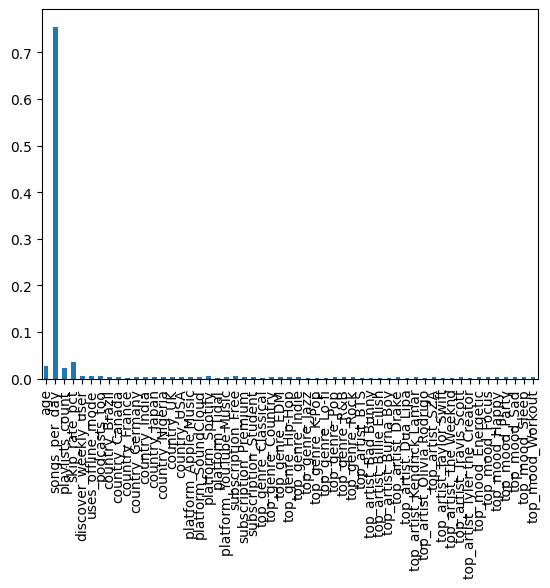

In [38]:
features.plot(kind='bar', legend=False)
plt.show()

In [39]:
X1 = df[['age', 'songs_per_day', 'playlists_count', 'skip_rate_pct']]
y1 = df['daily_listening_minutes']

In [40]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X1,y1,test_size=0.2,random_state=42)

In [41]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42)

In [42]:
model.fit(X_train,y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,15
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [43]:
pp = model.predict(X_test)

In [44]:
mean_squared_error(y_test,pp)

329.1082960959204

In [45]:
r2_score(y_test,pp)

0.9539883115385202

In [46]:
rmse = np.sqrt(329.1083)
rmse

18.141342287713993

In [47]:
import joblib
joblib.dump(model, "music_model.pkl", compress=9)

['music_model.pkl']

In [48]:
loaded_model = joblib.load('music_model.pkl')